In [27]:
import pandas as pd
import sqlite3
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

# Combine datasets

In [3]:
gaming_data = pd.read_csv('../data/gaming_GAD_CLEAN.csv')
nhis_data = pd.read_csv('../data/nhis_GAD_CLEAN.csv')

In [4]:
set(gaming_data.columns) ^ set(nhis_data.columns)

{'Degree',
 'Gender',
 'game',
 'hours',
 'participant_id_OLD',
 'platform',
 'playstyle',
 'reason',
 'region_id'}

In [5]:
df = pd.concat([gaming_data, nhis_data], ignore_index=True, sort=False)
df.head()

# Reference: https://pandas.pydata.org/docs/user_guide/merging.html

,Unnamed: 0,participant_id,year,GAD1,GAD2,GAD3,GAD4,GAD5,GAD6,GAD7,GAD_total,GAD_cat,sex_id,age,education_id,survey_id,residence,game,platform,hours,reason,playstyle,Gender,Degree,region_id,participant_id_OLD
0,0,1,2015,0,0,0,0,1,0,0,1,1,1,25,8,1,USA,Skyrim,"Console (PS, Xbox, ...)",15.0,having fun,Singleplayer,Male,Bachelor (or equivalent),NaN,NaN
1,1,2,2015,1,2,2,2,0,1,0,8,2,1,41,8,1,USA,Other,PC,8.0,having fun,Multiplayer - online - with strangers,Male,Bachelor (or equivalent),NaN,NaN
2,2,3,2015,0,2,2,0,0,3,1,8,2,2,32,8,1,DEU,Other,PC,0.0,having fun,Singleplayer,Female,Bachelor (or equivalent),NaN,NaN
3,3,4,2015,0,0,0,0,0,0,0,0,1,1,28,8,1,USA,Other,PC,20.0,improving,Multiplayer - online - with online acquaintanc...,Male,Bachelor (or equivalent),NaN,NaN
4,4,5,2015,2,1,2,2,2,3,2,14,3,1,19,12,1,KOR,Other,"Console (PS, Xbox, ...)",20.0,having fun,Multiplayer - online - with strangers,Male,High school diploma (or equivalent),NaN,NaN


# Build Relational Tables

In [6]:
# ================
# Fact tables
# ================

participant_df = df[['participant_id', 'survey_id', 'sex_id', 'education_id', 'residence', 'age', 'region_id']].drop_duplicates()

GAD_response_df = df[['participant_id', 'GAD1', 'GAD2', 'GAD3', 'GAD4', 'GAD5', 'GAD6', 'GAD7', 'GAD_total', 'GAD_cat']]

gamers_df = df[['participant_id', 'survey_id', 'game', 'platform', 'hours', 'reason', 'playstyle']].drop_duplicates()

# ================
# Lookup tables
# ================

survey_df = pd.DataFrame({
    'survey_id': [1, 2],
    'survey_name': ['Gamers', 'NHIS'],
    'year': [2015, 2019],
    'population':['global', 'America']
})


GAD_categories = {
    1:'None/Minimal', 
    2:'Mild', 
    3:'Moderate', 
    4:'Severe', 
    8:'Not Ascertained'
}

GAD_cat_df = (
    pd.Series(GAD_categories, name='cat_name')
        .rename_axis('GAD_cat')
        .reset_index()
)

sex_lookup = {
    1: 'Male', 
    2:'Female', 
    7:'Refused', 
    8:'Not Ascertained',
    9:"Don't Know"
}
sex_df = (
    pd.Series(sex_lookup, name='sex_name')
        .rename_axis('sex_id')
        .reset_index()
)


degree_lookup = {
    0:'Never attended/kindergarten only', 
    1: 'Grade 1-11',
    2: '12th grade, no diploma',
    3: 'GED or equivalent',
    4: 'High School Graduate',
    5: 'Some college, no degree',
    6: 'Associate degree: occupational, technical, or vocational program',
    7: 'Associate degree: academic program',
    8: "Bachelor's degree (Example: BA, AB, BS, BBA)",
    9: "Master's degree or equivalent (Example: MA, MS, MEng, MEd, MBA)",
    10: "Professional School degree (Example: MD, DDS, DVM, JD)",
    11: "Doctoral degree (Example: PhD, EdD)",
    12: "High school diploma (or equivalent)",
    13: "Ph.D., Psy. D., MD (or equivalent)",
    97: "Refused",
    98: "Not Ascertained",
    99:"Don't Know"
}
education_df = (
    pd.Series(degree_lookup, name='level')
        .rename_axis('education_id')
        .reset_index()
)


region_lookup = {
    1: 'Northeast',
    2: 'Midwest',
    3: 'South', 
    4: 'West'
}
region_df = (
    pd.Series(region_lookup, name='name')
        .rename_axis('region_id')
        .reset_index()
)

# I conferred with ChatGPT to decide how to set up the lookup tables
# it recommended using dictionaries to set them up to make it easier to 
# read and maintain. I did this for the longer ones

In [7]:
conn = sqlite3.connect('../data/mentalhealth.db')

participant_df.to_sql('participants', conn, index=False, if_exists='replace')
GAD_response_df.to_sql('responses', conn, index=False, if_exists='replace')
gamers_df.to_sql('gamers', conn, index=False, if_exists='replace')
survey_df.to_sql('survey', conn, index=False, if_exists='replace')
GAD_cat_df.to_sql('categories', conn, index=False, if_exists='replace')
sex_df.to_sql('sex', conn, index=False, if_exists='replace')
education_df.to_sql('education', conn, index=False, if_exists='replace')
region_df.to_sql('region', conn, index=False, if_exists='replace')

4

# Exploratory Data Analysis

## QUERIES

### Participant data and scores (all_data_scores_r)

In [ ]:
all_data_scores_q = """
SELECT
    p.participant_id,
    p.survey_id,
    p.sex_id,
    p.education_id,
    p.residence,
    p.age,
    p.region_id,
    r.GAD1,
    r.GAD2,
    r.GAD3,
    r.GAD4,
    r.GAD5,
    r.GAD6,
    r.GAD7,
    r.GAD_total,
    r.GAD_cat
FROM participants p
JOIN responses r on r.participant_id = p.participant_id
"""

all_data_scores_r = pd.read_sql(all_data_scores_q, conn)
all_data_scores_r

### Participant data and scores (USA) (usa_data_scores_r)

In [ ]:
usa_data_scores_q = """
SELECT
    p.participant_id,
    p.survey_id,
    p.sex_id,
    p.education_id,
    p.residence,
    p.age,
    p.region_id,
    r.GAD1,
    r.GAD2,
    r.GAD3,
    r.GAD4,
    r.GAD5,
    r.GAD6,
    r.GAD7,
    r.GAD_total,
    r.GAD_cat
FROM participants p
JOIN responses r on r.participant_id = p.participant_id
WHERE p.residence = "USA"
"""

usa_data_scores_r = pd.read_sql(usa_data_scores_q, conn)
usa_data_scores_r

### NHIS data and scores (nhis_data_scores_r)

In [ ]:
nhis_data_scores_q = """
SELECT
    p.participant_id,
    p.survey_id,
    p.sex_id,
    p.education_id,
    p.residence,
    p.age,
    p.region_id,
    r.GAD1,
    r.GAD2,
    r.GAD3,
    r.GAD4,
    r.GAD5,
    r.GAD6,
    r.GAD7,
    r.GAD_total,
    r.GAD_cat
FROM participants p
JOIN responses r on r.participant_id = p.participant_id
WHERE p.survey_id = 2
"""

nhis_data_scores_r = pd.read_sql(nhis_data_scores_q, conn)
nhis_data_scores_r

### Gamer data and scores (USA) (usa_gamer_data_scores_r)

In [ ]:
usa_gamer_data_scores_q = """
SELECT
    p.participant_id,
    p.survey_id,
    p.sex_id,
    p.education_id,
    p.residence,
    p.age,
    p.region_id,
    r.GAD1,
    r.GAD2,
    r.GAD3,
    r.GAD4,
    r.GAD5,
    r.GAD6,
    r.GAD7,
    r.GAD_total,
    r.GAD_cat
FROM participants p
JOIN responses r on r.participant_id = p.participant_id
WHERE p.survey_id = 1
    AND p.residence = "USA"
"""

usa_gamer_data_scores_r = pd.read_sql(usa_gamer_data_scores_q, conn)
usa_gamer_data_scores_r

### Gamer data and scores (World) (all_gamer_data_scores_r)

In [ ]:
all_gamer_data_scores_q = """
SELECT
    p.participant_id,
    p.survey_id,
    p.sex_id,
    p.education_id,
    p.residence,
    p.age,
    p.region_id,
    r.GAD1,
    r.GAD2,
    r.GAD3,
    r.GAD4,
    r.GAD5,
    r.GAD6,
    r.GAD7,
    r.GAD_total,
    r.GAD_cat
FROM participants p
JOIN responses r on r.participant_id = p.participant_id
WHERE p.survey_id = 1
"""

all_gamer_data_scores_r = pd.read_sql(all_gamer_data_scores_q, conn)
all_gamer_data_scores_r

### Scores by sex (sex_data_scores_r)

In [ ]:
sex_data_scores_q = """
SELECT
    p.sex_id,
    s.sex_name,
    AVG(r.GAD1),
    AVG(r.GAD2),
    AVG(r.GAD3),
    AVG(r.GAD4),
    AVG(r.GAD5),
    AVG(r.GAD6),
    AVG(r.GAD7),
    AVG(r.GAD_total),
    AVG(r.GAD_cat),
    count(p.sex_id) as total_participants
FROM participants p
JOIN responses r on r.participant_id = p.participant_id
JOIN sex s on s.sex_id = p.sex_id
GROUP BY p.sex_id
"""

sex_data_scores_r = pd.read_sql(sex_data_scores_q, conn)
sex_data_scores_r

### Scores by age (usa_age_data_scores_r)
Note that this *may* skew results somewhat as the primary participants of the gamer survey were in their early 20s.

In [ ]:
usa_age_data_scores_q = """
SELECT
    p.age,
    AVG(r.GAD1),
    AVG(r.GAD2),
    AVG(r.GAD3),
    AVG(r.GAD4),
    AVG(r.GAD5),
    AVG(r.GAD6),
    AVG(r.GAD7),
    AVG(r.GAD_total),
    AVG(r.GAD_cat),
    count(p.age) as total_participants
FROM participants p
JOIN responses r on r.participant_id = p.participant_id
GROUP BY p.age
"""

usa_age_data_scores_r = pd.read_sql(usa_age_data_scores_q, conn)
usa_age_data_scores_r

### Scores by education (all_gamer_data_scores_r)

In [ ]:
all_gamer_data_scores_q = """
SELECT
    p.education_id,
    AVG(r.GAD1),
    AVG(r.GAD2),
    AVG(r.GAD3),
    AVG(r.GAD4),
    AVG(r.GAD5),
    AVG(r.GAD6),
    AVG(r.GAD7),
    AVG(r.GAD_total),
    AVG(r.GAD_cat),
    count(p.education_id) as total_participants
FROM participants p
JOIN responses r on r.participant_id = p.participant_id
GROUP BY p.education_id
"""

all_gamer_data_scores_r = pd.read_sql(all_gamer_data_scores_q, conn)
all_gamer_data_scores_r

## Visualizations

- box & whisker plot of scores (total and by survey)

### Heat map: Is there an observable and unexptected correlation in the data?

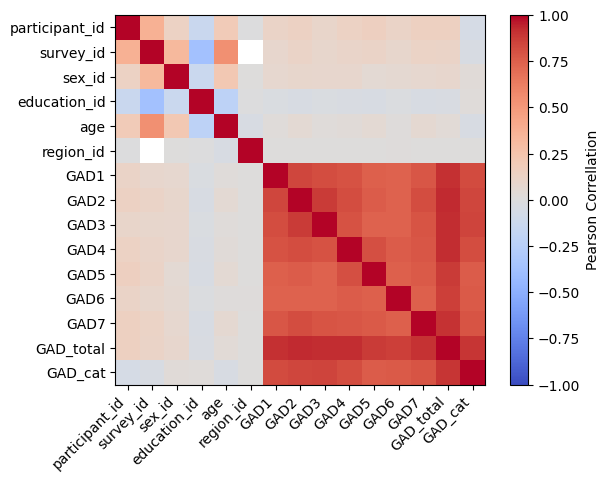

In [28]:
numeric_usa_df = usa_data_scores_r.select_dtypes(include=[np.number])
corr = numeric_usa_df.corr()

im = plt.imshow(corr, vmin=-1, vmax=1, cmap='coolwarm')
plt.colorbar(im, label='Pearson Correllation')

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
plt.yticks(range(len(corr.columns)), corr.columns)

plt.show()

There do not appear to be any strong, unexpected correlations revealed by this heat map.

### Pie chart: What is the division of participants' identified sex?

In [30]:
category = 'sex_name'
values = 'total_participants'

sex_totals = sex_data_scores_r.groupby(category)[values].sum()
sex_totals

sex_name
Female     21929
Male       36717
Refused        3
Name: total_participants, dtype: int64

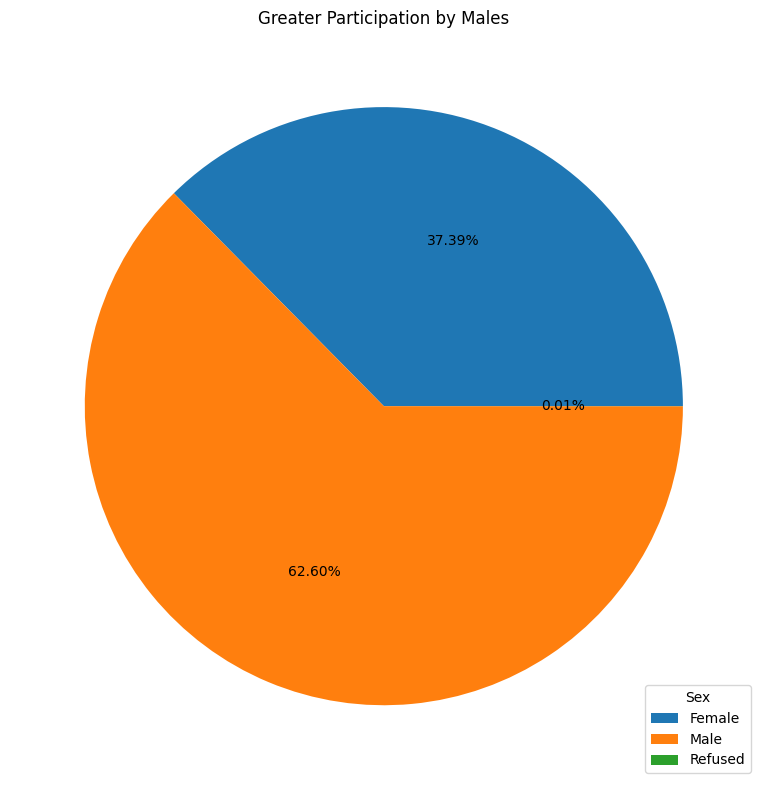

In [33]:
plt.figure(figsize=(8,8))
plt.pie(
    sex_totals,
    labels=None,
    autopct='%1.2f%%'
)

plt.title('Greater Participation by Males')

plt.legend(
    labels=sex_totals.index,
    loc='lower right',
    title='Sex'
)

plt.tight_layout()
plt.show()

### Bar chart: What is the average GAD score for each survey? (USA)

In [ ]:
usa_data_scores_r

,participant_id,survey_id,sex_id,education_id,residence,age,region_id,GAD1,GAD2,GAD3,GAD4,GAD5,GAD6,GAD7,GAD_total,GAD_cat
0,1,1,1,8,USA,25,NaN,0,0,0,0,1,0,0,1,1
1,2,1,1,8,USA,41,NaN,1,2,2,2,0,1,0,8,2
2,4,1,1,8,USA,28,NaN,0,0,0,0,0,0,0,0,1
3,6,1,1,8,USA,24,NaN,0,0,0,0,0,1,0,1,1
4,6,1,1,8,USA,24,NaN,1,1,1,1,1,1,1,7,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45530,46022,2,2,7,USA,68,4.0,1,1,1,1,1,1,1,7,1
45531,46232,2,1,5,USA,47,4.0,1,1,1,1,1,1,1,7,1
45532,43765,2,1,5,USA,68,4.0,1,1,1,1,1,2,1,8,1
45533,17695,2,2,7,USA,31,4.0,1,1,2,1,1,1,1,8,1


In [37]:
avg_score = usa_data_scores_r.groupby('survey_id')['GAD_total'].mean()
avg_score

survey_id
1    6.904706
2    9.262735
Name: GAD_total, dtype: float64

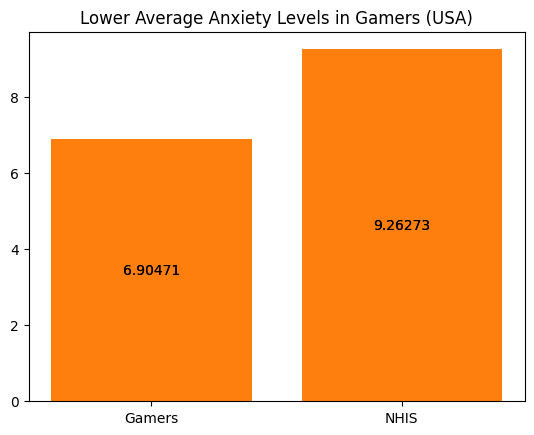

In [49]:
surveys = ('Gamers', 'NHIS')

fig, ax = plt.subplots()
bottom = np.zeros(2)

for survey in avg_score.items():
    p = ax.bar(surveys, avg_score, label=survey, bottom=bottom)
    ax.bar_label(p, label_type='center')

ax.set_title('Lower Average Anxiety Levels in Gamers (USA)')

plt.show()

# Reference: 
#   x-tick labels: https://matplotlib.org/stable/gallery/lines_bars_and_markers/bar_label_demo.html

### Count plots of avg scores
  - totals
  - by survey
  - (total and by survey)
    - by sex
    - by age
    - by education

#### How do the GAD score totals compare across all participants?

In [50]:
usa_data_scores_r

,participant_id,survey_id,sex_id,education_id,residence,age,region_id,GAD1,GAD2,GAD3,GAD4,GAD5,GAD6,GAD7,GAD_total,GAD_cat
0,1,1,1,8,USA,25,NaN,0,0,0,0,1,0,0,1,1
1,2,1,1,8,USA,41,NaN,1,2,2,2,0,1,0,8,2
2,4,1,1,8,USA,28,NaN,0,0,0,0,0,0,0,0,1
3,6,1,1,8,USA,24,NaN,0,0,0,0,0,1,0,1,1
4,6,1,1,8,USA,24,NaN,1,1,1,1,1,1,1,7,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45530,46022,2,2,7,USA,68,4.0,1,1,1,1,1,1,1,7,1
45531,46232,2,1,5,USA,47,4.0,1,1,1,1,1,1,1,7,1
45532,43765,2,1,5,USA,68,4.0,1,1,1,1,1,2,1,8,1
45533,17695,2,2,7,USA,31,4.0,1,1,2,1,1,1,1,8,1


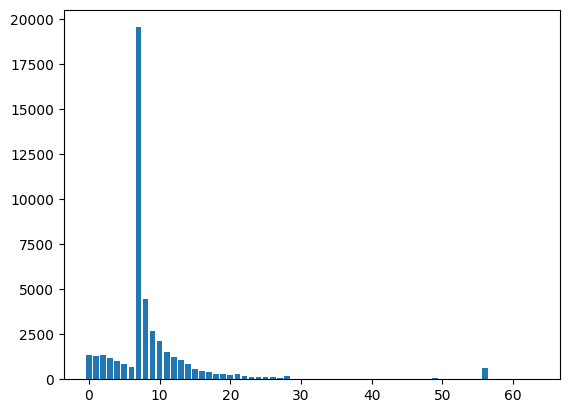

In [51]:
usa_score_count = usa_data_scores_r['GAD_total'].value_counts()

plt.bar(usa_score_count.index, usa_score_count.values)

plt.show()

In [ ]:
# investigating  why any number is above total possible GAD score of 21
usa_data_scores_r['GAD_total'].unique()

array([ 1,  8,  0,  7, 10, 12, 19,  3,  4,  6, 14, 56,  5, 11,  2,  9, 18,
       21, 17, 22, 16, 15, 13, 49, 63, 23, 26, 20, 28, 25, 24, 27, 51, 37,
       31, 47, 29, 40, 39, 55, 34, 42, 30, 32, 36, 50, 38, 46, 43, 33, 44])

In [ ]:
filtered_scores = usa_data_scores_r.loc[usa_data_scores_r['GAD_total'] > 21]
filtered_scores

# I'm stepping away for now. The highest number that SHOULD be possible in the GAD1-7 columns is 3.

,participant_id,survey_id,sex_id,education_id,residence,age,region_id,GAD1,GAD2,GAD3,GAD4,GAD5,GAD6,GAD7,GAD_total,GAD_cat
28,43,1,1,8,USA,27,NaN,8,8,8,8,8,8,8,56,8
80,177,1,1,99,USA,18,NaN,4,4,4,4,1,1,4,22,4
222,619,1,1,12,USA,23,NaN,8,8,8,8,8,8,8,56,8
242,692,1,1,8,USA,22,NaN,7,7,7,7,7,7,7,49,8
258,752,1,1,12,USA,20,NaN,8,8,8,8,8,8,8,56,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45499,56350,2,1,4,USA,84,2.0,8,8,8,8,8,8,8,56,8
45504,13564,2,2,7,USA,61,2.0,4,4,4,4,4,4,4,28,4
45507,4069,2,1,5,USA,39,4.0,3,4,4,4,4,1,4,24,4
45527,44645,2,1,4,USA,40,4.0,4,4,4,4,3,3,3,25,4


#### How do the GAD score totals compare across USA gamer participants?

#### How do the GAD score totals compare across NHIS participants?